Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

#sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, BayesianRidge, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('All imports OK')

All imports OK


In [2]:
df = pd.read_csv("data/top_rated_movies.csv")
df.head()

,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
0,0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,1994-09-23,32.2333,8.715,29566
1,1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,33.8438,8.686,22328
2,2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,1974-12-20,19.5095,8.570,13501
3,3,424,Schindler's List,The true story of how businessman Oskar Schind...,1993-12-15,14.6770,8.600,17015
4,4,389,12 Angry Men,The defense and the prosecution have rested an...,1957-04-10,12.9954,8.600,9676


Data Loading & Cleaning

In [3]:
#handling null Values
df = df.dropna(subset=['overview', 'release_date'])

# type conversions
df['release_date'] = pd.to_datetime(df['release_date'])
df['year']       = df['release_date'].dt.year
df['month']      = df['release_date'].dt.month
df['month_name'] = df['release_date'].dt.month_name()
df['decade']     = (df['year'] // 10) * 10

#only keep movies with a number of votes >= 500
df = df[df['vote_count'] >= 500].copy()

#get rid of duplicates
df = df.drop_duplicates(subset=['id'])

print(f'Cleaned shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df[['vote_average','popularity','vote_count','year']].describe()


Cleaned shape: (7207, 12)
Missing values: 0


,vote_average,popularity,vote_count,year
count,7207.000000,7207.000000,7207.000000,7207.000000
mean,6.779462,4.654708,2721.625919,2005.019981
std,0.664852,9.574680,3694.072134,16.915822
min,5.400000,0.003100,500.000000,1902.000000
25%,6.283000,2.097750,767.000000,1998.000000
50%,6.760000,3.261900,1339.000000,2010.000000
75%,7.277000,5.330800,2966.500000,2017.000000
max,8.715000,567.760800,38665.000000,2026.000000


Feature Engineering

In [4]:
# minimal positive/negative lexicon 
POSITIVE = set([
    'love','great','best','good','beautiful','wonderful','amazing','brilliant',
    'outstanding','excellent','perfect','magnificent','triumph','hope','joy',
    'heroic','brave','kind','success','win','winning','happy','celebrated',
    'legendary','inspiring','powerful','passionate','friendship','freedom',
    'redemption','courage','honest','faithful','glorious','noble','wise',
    'genius','masterpiece','extraordinary','remarkable','heartwarming','classic'
])
NEGATIVE = set([
    'murder','kill','death','war','hate','evil','dark','crime','horror',
    'terror','fear','brutal','violent','corrupt','betrayal','tragedy','pain',
    'suffer','loss','blood','danger','threat','revenge','destroy','chaos',
    'desperate','sinister','ruthless','massacre','catastrophe','abuse','flee',
    'prison','escape','corrupt','lies','deception','broken','lost','dead'
])

def sentiment_score(text):
    """Returns (polarity, subjectivity-proxy) for an overview string."""
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    if not words:
        return 0.0, 0.0
    pos = sum(1 for w in words if w in POSITIVE)
    neg = sum(1 for w in words if w in NEGATIVE)
    total = pos + neg
    polarity    = (pos - neg) / len(words)          # net positivity per word
    subjectivity = total / len(words)               # how "loaded" the overview is
    return polarity, subjectivity

#new columns created from the overview text. they're used as model features and as clustering features
df[['sentiment_polarity', 'sentiment_subjectivity']] = df['overview'].apply(
    lambda x: pd.Series(sentiment_score(x))
)

# overview length
df['overview_len'] = df['overview'].apply(lambda x: len(str(x).split()))

# log-transform skewed features
df['log_popularity']  = np.log1p(df['popularity'])
df['log_vote_count']  = np.log1p(df['vote_count'])

# oscar season flag (nov/dec release)
df['oscar_season'] = df['month'].isin([11, 12]).astype(int)

# year normalized (for trend modeling)
df['year_norm'] = (df['year'] - df['year'].mean()) / df['year'].std()

print('Feature engineering complete.')
df[['sentiment_polarity','sentiment_subjectivity','overview_len',
    'log_popularity','oscar_season']].describe()

Feature engineering complete.


,sentiment_polarity,sentiment_subjectivity,overview_len,log_popularity,oscar_season
count,7207.000000,7207.000000,7207.000000,7207.000000,7207.000000
mean,-0.003836,0.018270,44.845151,1.526528,0.190787
std,0.024485,0.023731,21.405146,0.549743,0.392949
min,-0.200000,0.000000,6.000000,0.003095,0.000000
25%,-0.014706,0.000000,28.000000,1.130676,0.000000
50%,0.000000,0.012048,40.000000,1.449715,0.000000
75%,0.000000,0.030303,59.000000,1.845427,0.000000
max,0.187500,0.312500,159.000000,6.343460,1.000000


EDA

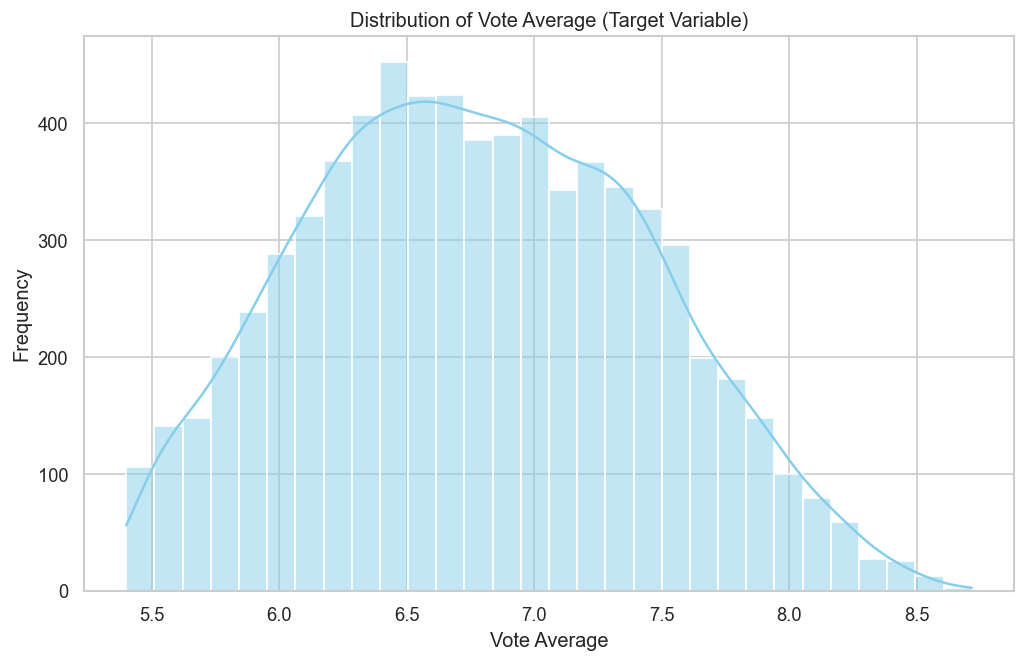

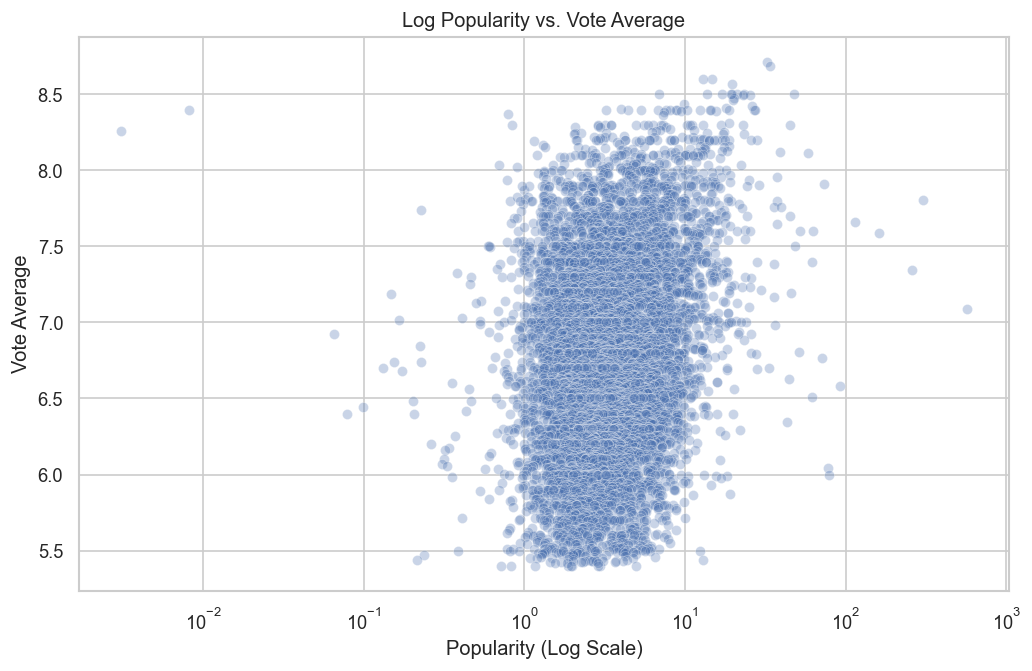

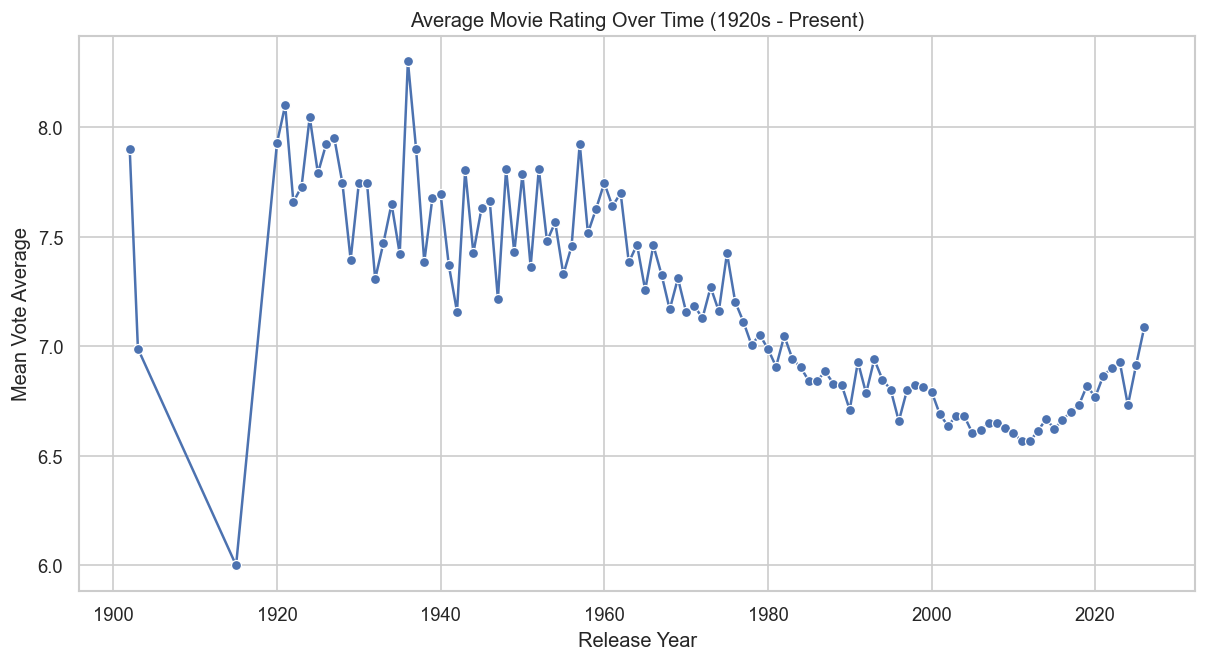

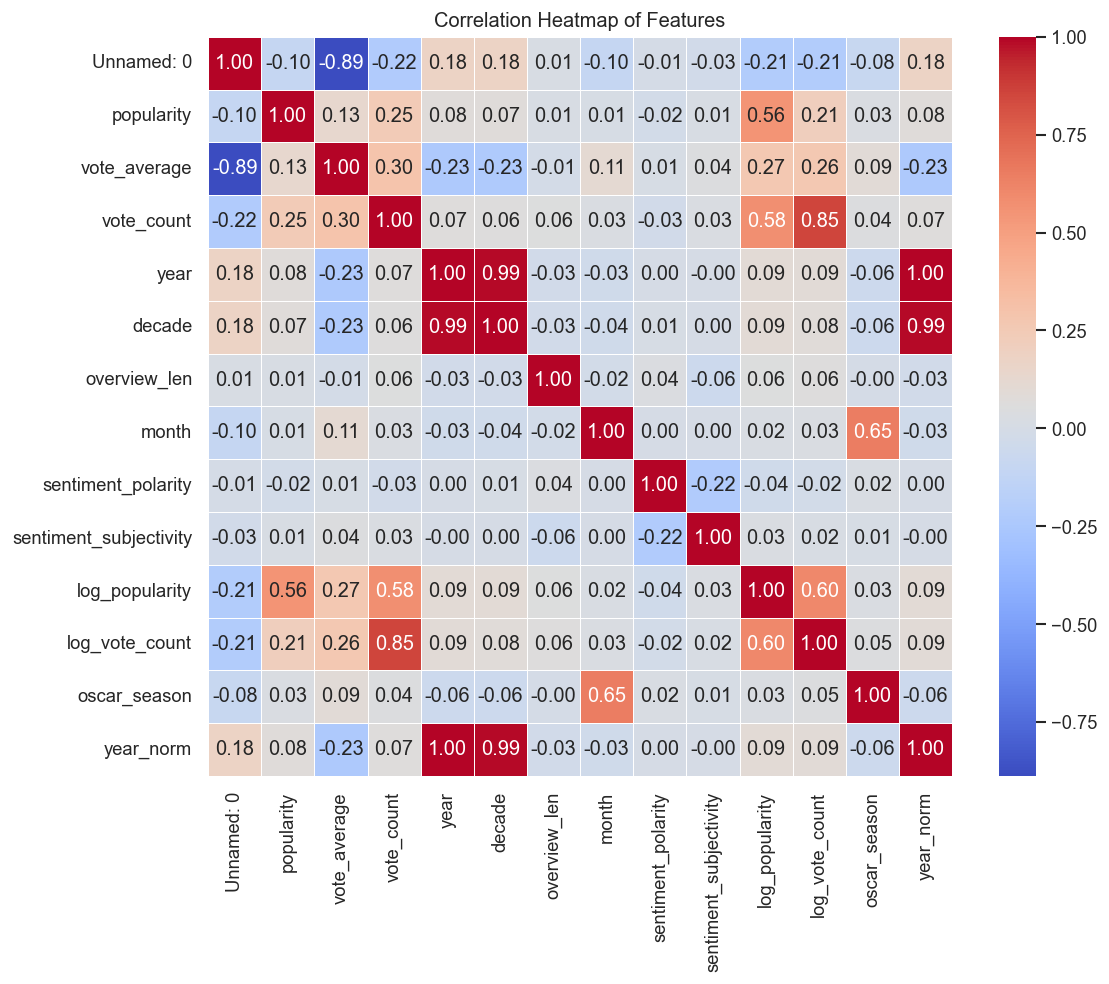

/var/folders/8s/lld731n53b9_dd_7v8p9gskr0000gn/T/ipykernel_31265/4070073375.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=decade_counts, x='decade', y='count', palette='viridis')


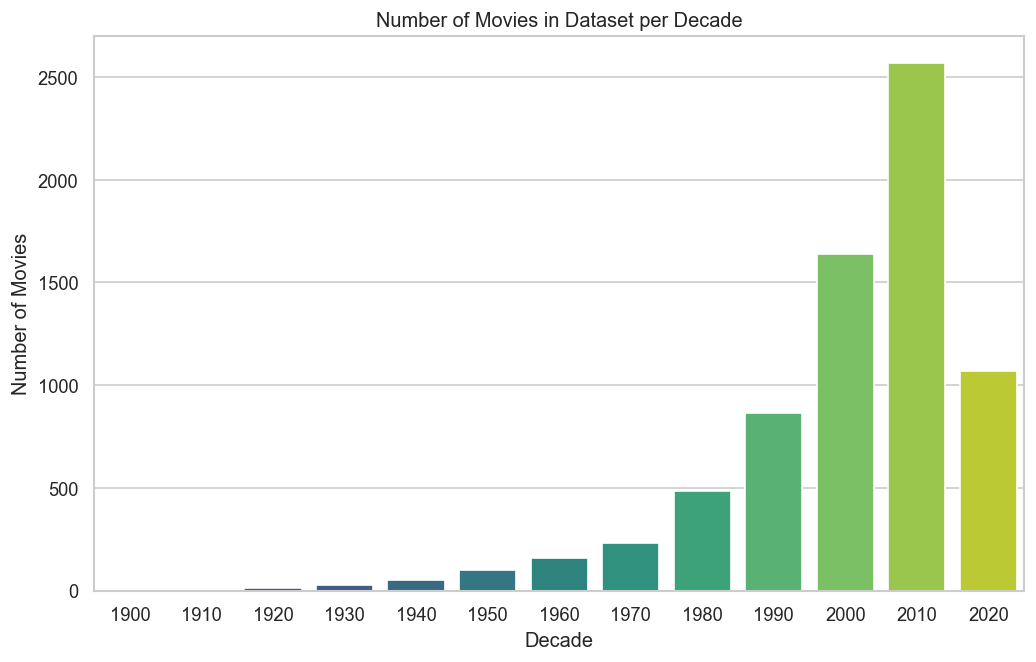

       vote_average   popularity    vote_count         year
count   7207.000000  7207.000000   7207.000000  7207.000000
mean       6.779462     4.654708   2721.625919  2005.019981
std        0.664852     9.574680   3694.072134    16.915822
min        5.400000     0.003100    500.000000  1902.000000
25%        6.283000     2.097750    767.000000  1998.000000
50%        6.760000     3.261900   1339.000000  2010.000000
75%        7.277000     5.330800   2966.500000  2017.000000
max        8.715000   567.760800  38665.000000  2026.000000


In [13]:
df['overview_len'] = df['overview'].apply(lambda x: len(str(x).split()))

#plotting style
sns.set_theme(style="whitegrid")

#1. distribution of target variable (vote_average)
plt.figure(figsize=(10, 6))
sns.histplot(df['vote_average'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Vote Average (Target Variable)')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')
plt.show()

#2. popularity vs. vote average 
#use log scale for popularity because it's usually skewed
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='popularity', y='vote_average', alpha=0.3)
plt.xscale('log')
plt.title('Log Popularity vs. Vote Average')
plt.xlabel('Popularity (Log Scale)')
plt.ylabel('Vote Average')
plt.show()

#3. average rating over time (years)
yearly_stats = df.groupby('year')['vote_average'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='year', y='vote_average', marker='o')
plt.title('Average Movie Rating Over Time (1920s - Present)')
plt.xlabel('Release Year')
plt.ylabel('Mean Vote Average')
plt.show()

#4. correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['id'])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

#5. movies per decade
df['decade'] = (df['year'] // 10) * 10
decade_counts = df['decade'].value_counts().sort_index().reset_index()
decade_counts.columns = ['decade', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=decade_counts, x='decade', y='count', palette='viridis')
plt.title('Number of Movies in Dataset per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.show()


# Output summary of findings
print(df[['vote_average', 'popularity', 'vote_count', 'year']].describe())

Does overview sentiment predict ratings?

/var/folders/8s/lld731n53b9_dd_7v8p9gskr0000gn/T/ipykernel_31265/845514781.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rating_quartile', y='sentiment_polarity',


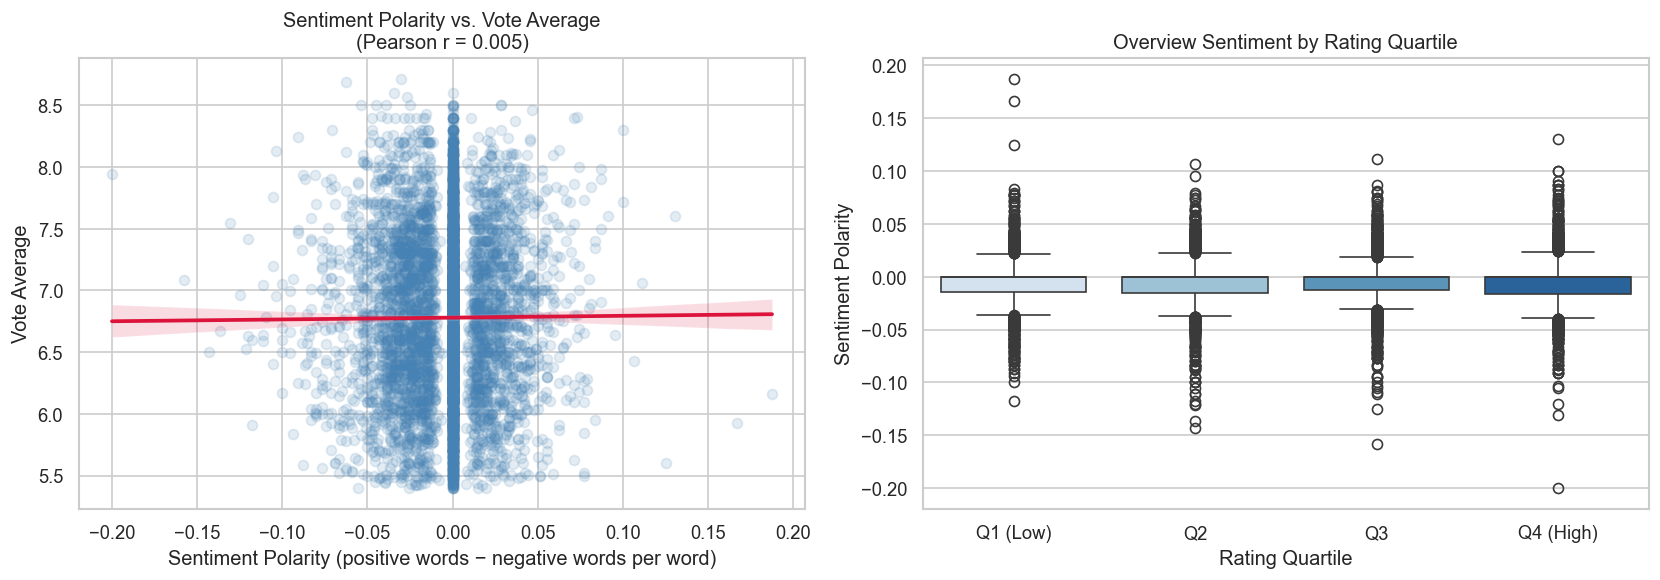

                  count    mean     std     min     25%  50%  75%     max
rating_quartile                                                          
Q1 (Low)         1804.0 -0.0040  0.0244 -0.1176 -0.0145  0.0  0.0  0.1875
Q2               1800.0 -0.0045  0.0242 -0.1429 -0.0149  0.0  0.0  0.1064
Q3               1803.0 -0.0030  0.0240 -0.1579 -0.0123  0.0  0.0  0.1111
Q4 (High)        1800.0 -0.0039  0.0254 -0.2000 -0.0159  0.0  0.0  0.1304


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#sentiment polarity vs vote_average
sns.regplot(data=df, x='sentiment_polarity', y='vote_average',
            scatter_kws={'alpha': 0.15, 'color':'steelblue'},
            line_kws={'color': 'crimson'}, ax=axes[0])
r = df['sentiment_polarity'].corr(df['vote_average'])
axes[0].set_title(f'Sentiment Polarity vs. Vote Average\n(Pearson r = {r:.3f})')
axes[0].set_xlabel('Sentiment Polarity (positive words − negative words per word)')
axes[0].set_ylabel('Vote Average')

#distribution of polarity by rating quartile
df['rating_quartile'] = pd.qcut(df['vote_average'], 4,
                                 labels=['Q1 (Low)','Q2','Q3','Q4 (High)'])
sns.boxplot(data=df, x='rating_quartile', y='sentiment_polarity',
            palette='Blues', ax=axes[1])
axes[1].set_title('Overview Sentiment by Rating Quartile')
axes[1].set_xlabel('Rating Quartile')
axes[1].set_ylabel('Sentiment Polarity')

plt.tight_layout()
plt.savefig('eda_sentiment_vs_rating.png', bbox_inches='tight')
plt.show()

print(df.groupby('rating_quartile')['sentiment_polarity'].describe().round(4))


Popularity vs Ratings: Signal or Noise? 

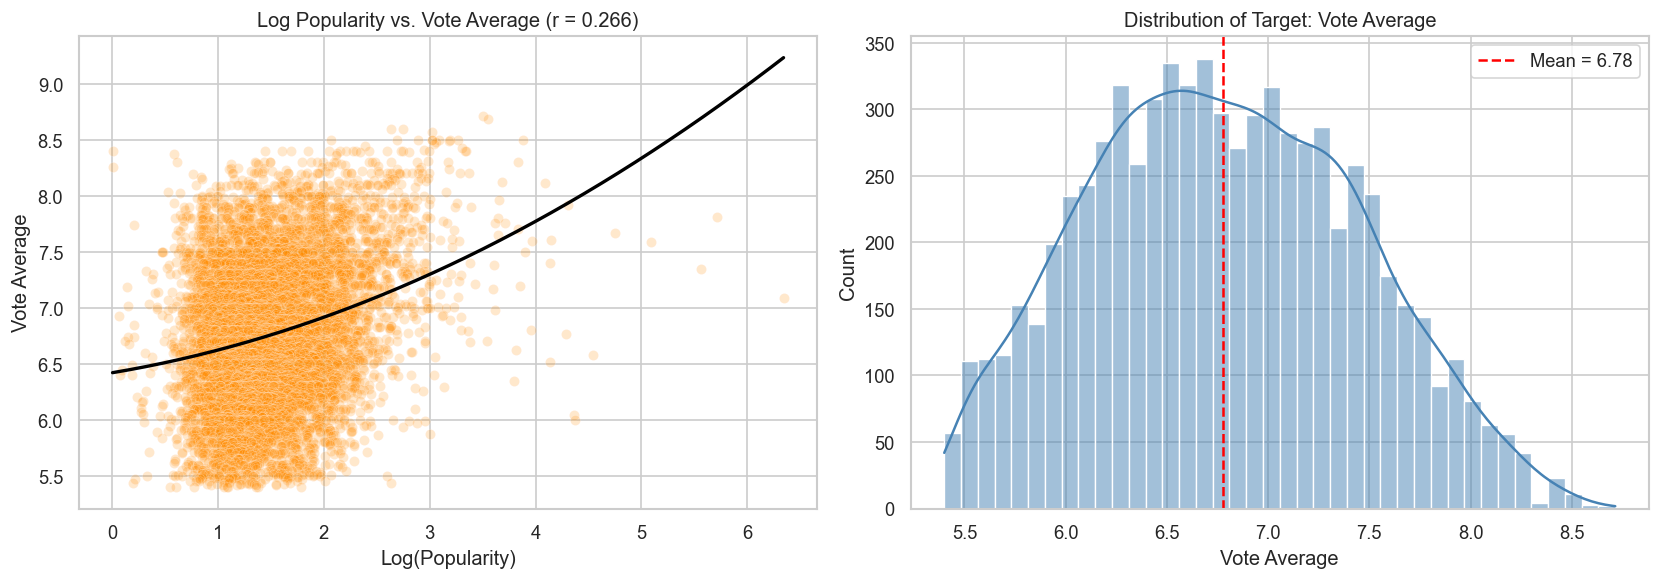

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='log_popularity', y='vote_average',
                alpha=0.2, ax=axes[0], color='darkorange')
#adding smoothing line
z = np.polyfit(df['log_popularity'], df['vote_average'], 2)
p = np.poly1d(z)
x_line = np.linspace(df['log_popularity'].min(), df['log_popularity'].max(), 200)
axes[0].plot(x_line, p(x_line), color='black', linewidth=2)
r = df['log_popularity'].corr(df['vote_average'])
axes[0].set_title(f'Log Popularity vs. Vote Average (r = {r:.3f})')
axes[0].set_xlabel('Log(Popularity)')
axes[0].set_ylabel('Vote Average')

#distribution of target variable: vote_average 
sns.histplot(df['vote_average'], bins=40, kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(df['vote_average'].mean(), color='red', linestyle='--', label=f'Mean = {df["vote_average"].mean():.2f}')
axes[1].set_title('Distribution of Target: Vote Average')
axes[1].set_xlabel('Vote Average')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_popularity_target.png', bbox_inches='tight')
plt.show()

Temporal Trends in Ratings and Sentiment

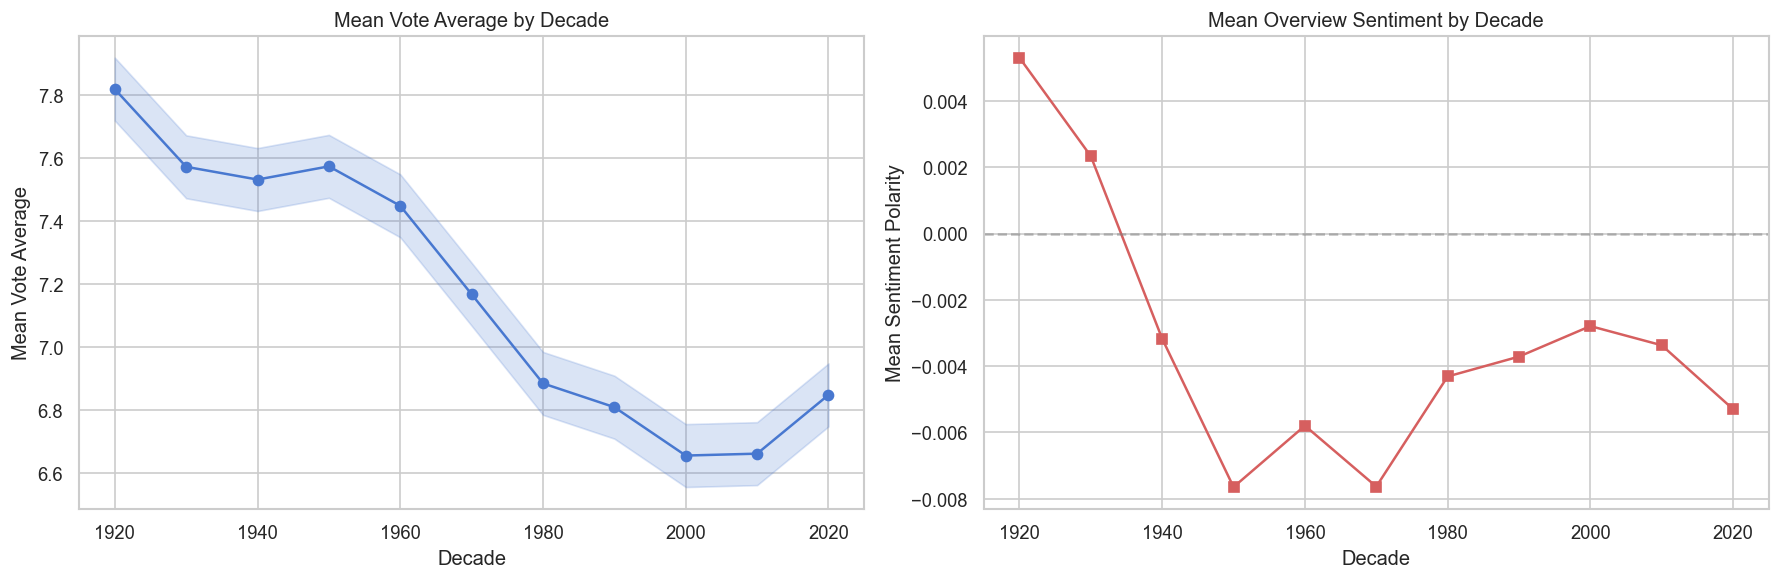

In [35]:
#aggregate by decade using groupby
decade_agg = df.groupby('decade').agg(
    mean_rating=('vote_average','mean'),
    mean_sentiment=('sentiment_polarity','mean'),
    n_movies=('id','count')
).reset_index()
decade_agg = decade_agg[decade_agg['n_movies'] >= 10]  # only decades with more than 10 films

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

color1 = sns.color_palette('muted')[0]
color2 = sns.color_palette('muted')[3]

axes[0].plot(decade_agg['decade'], decade_agg['mean_rating'], 'o-', color=color1)
axes[0].fill_between(decade_agg['decade'], decade_agg['mean_rating'] - 0.1,
                     decade_agg['mean_rating'] + 0.1, alpha=0.2, color=color1)
axes[0].set_title('Mean Vote Average by Decade')
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Mean Vote Average')

axes[1].plot(decade_agg['decade'], decade_agg['mean_sentiment'], 's-', color=color2)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Mean Overview Sentiment by Decade')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Mean Sentiment Polarity')

plt.tight_layout()
plt.savefig('eda_temporal.png', bbox_inches='tight')
plt.show()


Unsupervised Clustering

In [ ]:
cluster_features = ['log_popularity','log_vote_count','sentiment_polarity',
                    'sentiment_subjectivity','overview_len','year_norm']

#drops any rows with missing values from 6 clustering features
X_clust = df[cluster_features].dropna()
idx_valid = X_clust.index

#standardizes cluster indexes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

#find best K using silhouette score
K_range = range(2, 10) #loops through K=2 to 9
sil_scores = [silhouette_score(X_scaled, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)) for k in K_range]

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'Best K by silhouette: {best_k}')

Best K by silhouette: 3


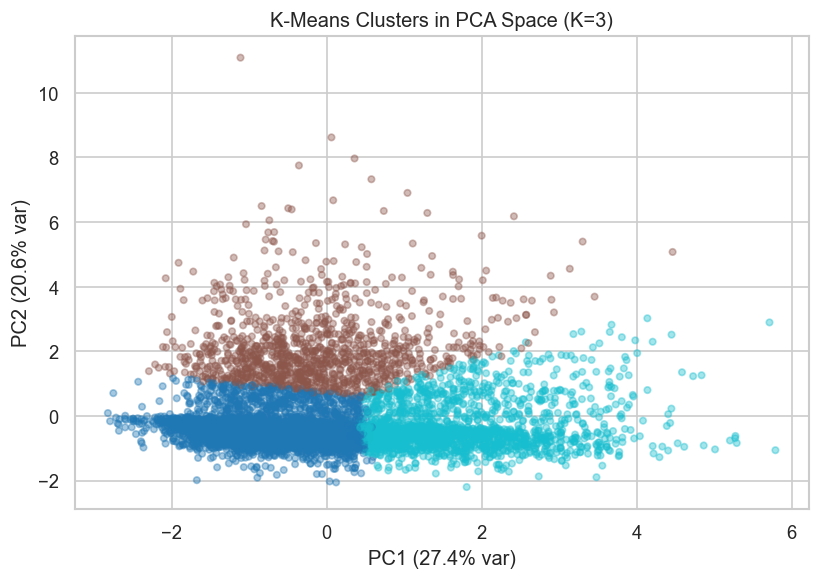

In [ ]:
#fit final K-Means with best_k
K_FINAL = best_k
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)
df.loc[idx_valid, 'cluster'] = cluster_labels
df['cluster'] = df['cluster'].fillna(-1).astype(int)
df_valid = df[df['cluster'] >= 0]

# 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

#plot clusters
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.4, s=15)
plt.title(f'K-Means Clusters in PCA Space (K={K_FINAL})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.savefig('clustering_results.png', bbox_inches='tight')
plt.show()

Cluster Profiles (mean values):
         log_popularity  log_vote_count  sentiment_polarity  sentiment_subjectivity  overview_len  year_norm  vote_average    decade
cluster                                                                                                                             
0                 1.271           6.941               0.004                   0.011        45.730     -0.083         6.681  1999.158
1                 1.436           7.181              -0.039                   0.053        34.676     -0.032         6.749  1999.945
2                 2.124           8.524              -0.001                   0.015        48.623      0.195         7.007  2003.828

--- Cluster Interpretation ---
Examine cluster_profile above to label clusters, e.g.:
  High log_popularity + high log_vote_count → "Blockbuster" cluster
  High sentiment_polarity + high vote_average → "Feel-good classics" cluster
  Negative sentiment, older decade → "Dark/dramatic classics" cluster


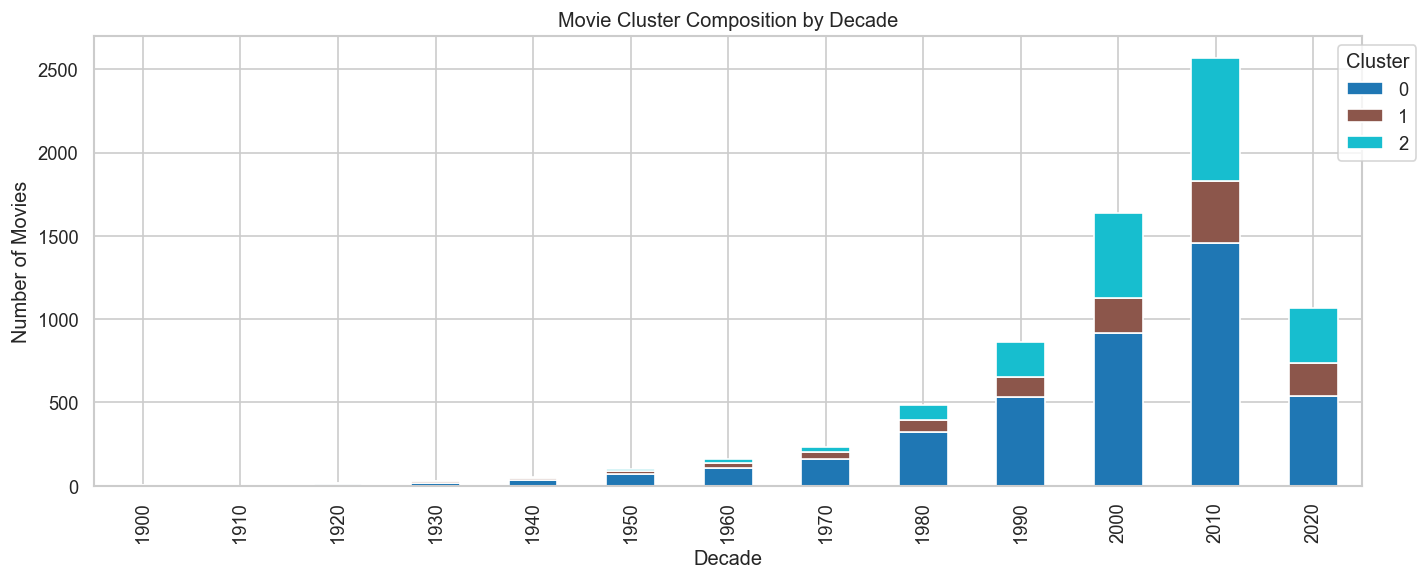

In [ ]:
#cluster profiles — what characterizes each cluster?
#groups by cluster and takes the mean of every feature plus vote_avg and decade
profile_cols = cluster_features + ['vote_average','decade']
cluster_profile = df[df['cluster'] >= 0].groupby('cluster')[profile_cols].mean().round(3)
print('Cluster Profiles (mean values):')
print(cluster_profile.to_string())

#assign interpretive labels based on profiles
print('\n--- Cluster Interpretation ---')
print('Examine cluster_profile above to label clusters, e.g.:')
print('  High log_popularity + high log_vote_count → "Blockbuster" cluster')
print('  High sentiment_polarity + high vote_average → "Feel-good classics" cluster')
print('  Negative sentiment, older decade → "Dark/dramatic classics" cluster')

#how many movies from each cluster appear in each decade 
decade_cluster = df[df['cluster'] >= 0].groupby(['decade','cluster']).size().unstack(fill_value=0)
decade_cluster.plot(kind='bar', stacked=True, figsize=(12,5), colormap='tab10')
plt.title('Movie Cluster Composition by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('cluster_by_decade.png', bbox_inches='tight')
plt.show()

Modeling Preparation

In [20]:
MODEL_FEATURES = [
    'sentiment_polarity',
    'sentiment_subjectivity',
    'overview_len',
    'log_popularity',
    'log_vote_count',
    'year_norm',
    'oscar_season'
]

df_model = df[MODEL_FEATURES + ['vote_average']].dropna()
X = df_model[MODEL_FEATURES].values
y = df_model['vote_average'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_m = StandardScaler()
X_train_s = scaler_m.fit_transform(X_train)
X_test_s  = scaler_m.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')
print(f'Target mean: {y_train.mean():.3f}, std: {y_train.std():.3f}')

Train: (5765, 7)  |  Test: (1442, 7)
Target mean: 6.775, std: 0.663


Model 1: OLS Linear Regression

=== OLS Linear Regression ===
  R²  (test):  0.1656
  RMSE (test): 0.6124
  MAE  (test): 0.5005
  5-fold CV R²: 0.1614 ± 0.0200


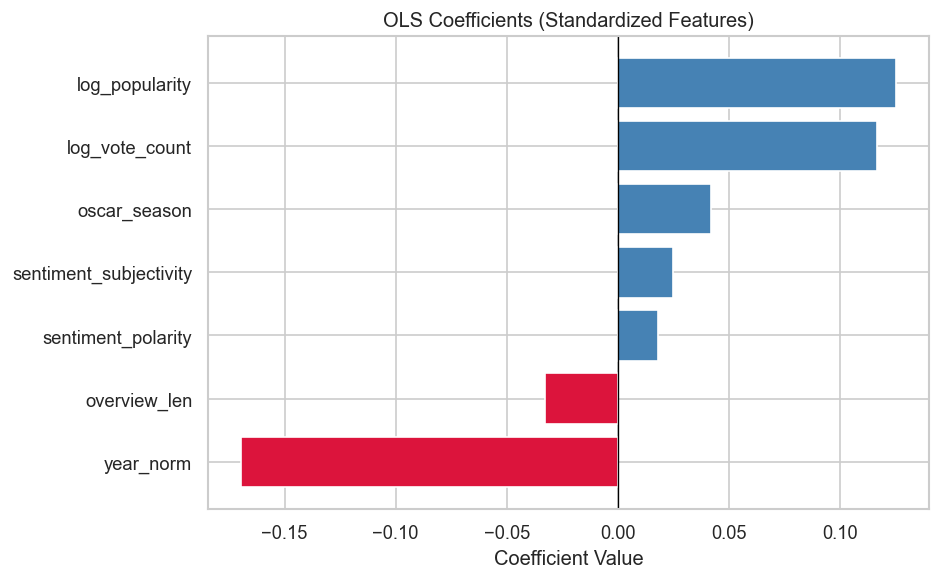


Coefficients:
                        coefficient
feature                            
year_norm                   -0.1697
overview_len                -0.0329
sentiment_polarity           0.0180
sentiment_subjectivity       0.0249
oscar_season                 0.0419
log_vote_count               0.1166
log_popularity               0.1253


In [ ]:
ols = LinearRegression()
ols.fit(X_train_s, y_train)
y_pred_ols = ols.predict(X_test_s)

ols_r2   = r2_score(y_test, y_pred_ols)
ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_mae  = mean_absolute_error(y_test, y_pred_ols)

#cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
ols_cv_r2 = cross_val_score(LinearRegression(), X_train_s, y_train, cv=cv, scoring='r2')

print('=== OLS Linear Regression ===')
print(f'  R²  (test):  {ols_r2:.4f}')
print(f'  RMSE (test): {ols_rmse:.4f}')
print(f'  MAE  (test): {ols_mae:.4f}')
print(f'  5-fold CV R²: {ols_cv_r2.mean():.4f} ± {ols_cv_r2.std():.4f}')

#coefficients
coef_df = pd.DataFrame({'feature': MODEL_FEATURES, 'coefficient': ols.coef_})\
           .sort_values('coefficient')

plt.figure(figsize=(8, 5))
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('OLS Coefficients (Standardized Features)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('ols_coefficients.png', bbox_inches='tight')
plt.show()

print('\nCoefficients:')
print(coef_df.set_index('feature').round(4))

In [ ]:
#OLS Diagnostics
residuals_ols = y_test - y_pred_ols

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#fitted vs actual
axes[0].scatter(y_pred_ols, y_test, alpha=0.2, color='steelblue', s=10)
lims = [min(y_test.min(), y_pred_ols.min()), max(y_test.max(), y_pred_ols.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_title('OLS: Predicted vs. Actual')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

#residuals vs fitted
axes[1].scatter(y_pred_ols, residuals_ols, alpha=0.2, color='darkorange', s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('OLS: Residuals vs. Fitted')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')

#residual distribution
sns.histplot(residuals_ols, bins=40, kde=True, color='steelblue', ax=axes[2])
axes[2].set_title('OLS: Residual Distribution')
axes[2].set_xlabel('Residual')

plt.suptitle('OLS Diagnostic Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('ols_diagnostics.png', bbox_inches='tight')
plt.show()

Model 2: Bayesian Ridge Regression

=== Bayesian Ridge Regression ===
  R²   (test):  0.1655
  RMSE (test):  0.6124
  MAE  (test):  0.5007
  5-fold CV R²: 0.1614 ± 0.0198

  Estimated alpha (noise precision): 2.7199
  Estimated lambda (weight precision): 113.6567


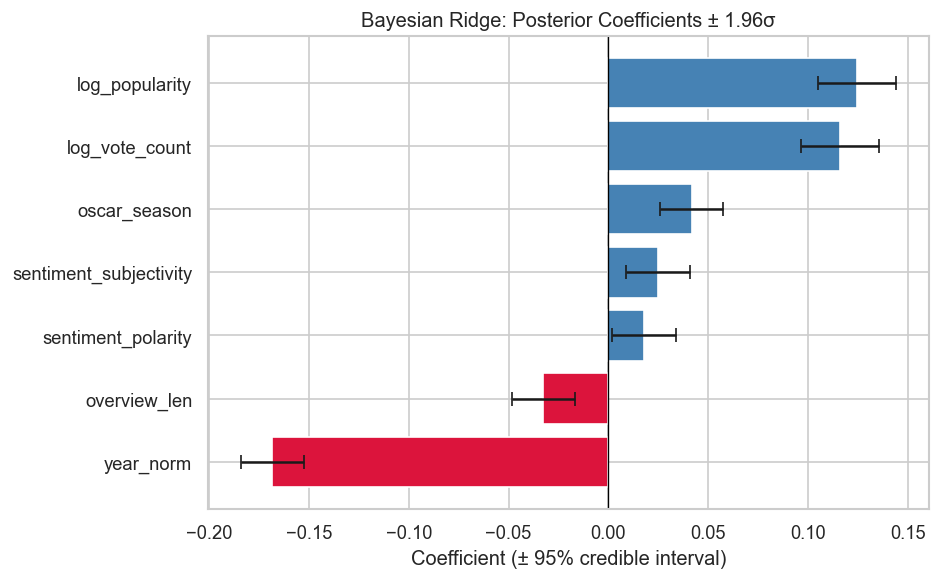


Coefficients:
                          coef   sigma
feature                               
year_norm              -0.1684  0.0080
overview_len           -0.0326  0.0080
sentiment_polarity      0.0178  0.0081
sentiment_subjectivity  0.0247  0.0081
oscar_season            0.0417  0.0080
log_vote_count          0.1160  0.0099
log_popularity          0.1246  0.0099


In [ ]:
bayes = BayesianRidge(compute_score=True, max_iter=1000)
bayes.fit(X_train_s, y_train)
y_pred_bayes, y_std_bayes = bayes.predict(X_test_s, return_std=True)

bayes_r2   = r2_score(y_test, y_pred_bayes)
bayes_rmse = np.sqrt(mean_squared_error(y_test, y_pred_bayes))
bayes_mae  = mean_absolute_error(y_test, y_pred_bayes)

bayes_cv_r2 = cross_val_score(BayesianRidge(), X_train_s, y_train, cv=cv, scoring='r2')

print('=== Bayesian Ridge Regression ===')
print(f'  R²   (test):  {bayes_r2:.4f}')
print(f'  RMSE (test):  {bayes_rmse:.4f}')
print(f'  MAE  (test):  {bayes_mae:.4f}')
print(f'  5-fold CV R²: {bayes_cv_r2.mean():.4f} ± {bayes_cv_r2.std():.4f}')
print(f'\n  Estimated alpha (noise precision): {bayes.alpha_:.4f}')
print(f'  Estimated lambda (weight precision): {bayes.lambda_:.4f}')

#coefficients with posterior uncertainty
bayes_coef_df = pd.DataFrame({
    'feature': MODEL_FEATURES,
    'coef': bayes.coef_,
    'sigma': np.sqrt(np.diag(bayes.sigma_))
}).sort_values('coef')

plt.figure(figsize=(8, 5))
plt.barh(bayes_coef_df['feature'], bayes_coef_df['coef'],
         xerr=1.96 * bayes_coef_df['sigma'],
         color=['crimson' if c < 0 else 'steelblue' for c in bayes_coef_df['coef']],
         capsize=4, error_kw={'elinewidth': 1.5})
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Bayesian Ridge: Posterior Coefficients ± 1.96σ')
plt.xlabel('Coefficient (± 95% credible interval)')
plt.tight_layout()
plt.savefig('bayesian_coefficients.png', bbox_inches='tight')
plt.show()

print('\nCoefficients:')
print(bayes_coef_df.set_index('feature').round(4))

In [ ]:
#visualize prediction uncertainty on a random sample
n_show = 100
idx_show = np.random.RandomState(0).choice(len(y_test), n_show, replace=False)
sort_idx = np.argsort(y_test[idx_show])

plt.figure(figsize=(12, 5))
x_plot = np.arange(n_show)
plt.plot(x_plot, y_test[idx_show][sort_idx], 'k.', ms=4, label='Actual')
plt.plot(x_plot, y_pred_bayes[idx_show][sort_idx], 'b-', lw=1.5, label='Predicted')
plt.fill_between(x_plot,
                 y_pred_bayes[idx_show][sort_idx] - 1.96 * y_std_bayes[idx_show][sort_idx],
                 y_pred_bayes[idx_show][sort_idx] + 1.96 * y_std_bayes[idx_show][sort_idx],
                 alpha=0.25, color='steelblue', label='95% Predictive Interval')
plt.title('Bayesian Ridge: Predictions with Uncertainty (sample of 100)')
plt.xlabel('Movie (sorted by actual rating)')
plt.ylabel('Vote Average')
plt.legend()
plt.tight_layout()
plt.savefig('bayesian_uncertainty.png', bbox_inches='tight')
plt.show()
print(f'Mean predictive std: {y_std_bayes.mean():.4f}')

Model 3: Gradient Boosting Regressor

=== Gradient Boosting Regressor ===
  R²   (test):  0.2211
  RMSE (test):  0.5917
  MAE  (test):  0.4794
  5-fold CV R²: 0.2122 ± 0.0290


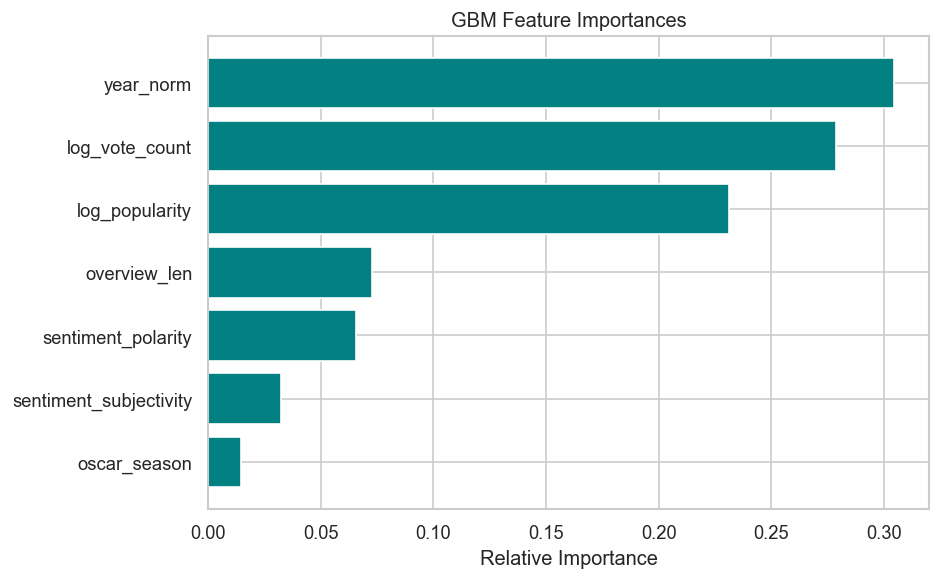


Feature Importances:
                        importance
feature                           
oscar_season                0.0145
sentiment_subjectivity      0.0325
sentiment_polarity          0.0655
overview_len                0.0729
log_popularity              0.2311
log_vote_count              0.2787
year_norm                   0.3047


In [ ]:
gbm = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gbm.fit(X_train_s, y_train)
y_pred_gbm = gbm.predict(X_test_s)

gbm_r2   = r2_score(y_test, y_pred_gbm)
gbm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbm))
gbm_mae  = mean_absolute_error(y_test, y_pred_gbm)

gbm_cv_r2 = cross_val_score(GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42
), X_train_s, y_train, cv=cv, scoring='r2')

print('=== Gradient Boosting Regressor ===')
print(f'  R²   (test):  {gbm_r2:.4f}')
print(f'  RMSE (test):  {gbm_rmse:.4f}')
print(f'  MAE  (test):  {gbm_mae:.4f}')
print(f'  5-fold CV R²: {gbm_cv_r2.mean():.4f} ± {gbm_cv_r2.std():.4f}')

#feature importances
imp_df = pd.DataFrame({'feature': MODEL_FEATURES, 'importance': gbm.feature_importances_})\
          .sort_values('importance')

plt.figure(figsize=(8, 5))
plt.barh(imp_df['feature'], imp_df['importance'], color='teal')
plt.title('GBM Feature Importances')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('gbm_importances.png', bbox_inches='tight')
plt.show()
print('\nFeature Importances:')
print(imp_df.set_index('feature').round(4))

In [ ]:
#partial dependence on top 2 features
top2 = imp_df.tail(2)['feature'].tolist()
print(f'Top 2 features by importance: {top2}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat in zip(axes, top2):
    feat_idx = MODEL_FEATURES.index(feat)
    x_range = np.linspace(X_train_s[:, feat_idx].min(),
                          X_train_s[:, feat_idx].max(), 100)
    X_pd = np.tile(X_train_s.mean(axis=0), (100, 1))
    X_pd[:, feat_idx] = x_range
    y_pd = gbm.predict(X_pd)
    ax.plot(x_range, y_pd, color='teal', lw=2)
    ax.set_title(f'Partial Dependence: {feat}')
    ax.set_xlabel(f'{feat} (standardized)')
    ax.set_ylabel('Predicted Vote Average')

plt.suptitle('GBM Partial Dependence Plots (all other features at mean)', y=1.02)
plt.tight_layout()
plt.savefig('gbm_partial_dep.png', bbox_inches='tight')
plt.show()

Model Comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['OLS (Classical)', 'Bayesian Ridge', 'Gradient Boosting'],
    'R² (test)': [ols_r2, bayes_r2, gbm_r2],
    'RMSE (test)': [ols_rmse, bayes_rmse, gbm_rmse],
    'MAE (test)': [ols_mae, bayes_mae, gbm_mae],
    'CV R² (mean)': [ols_cv_r2.mean(), bayes_cv_r2.mean(), gbm_cv_r2.mean()],
    'CV R² (std)': [ols_cv_r2.std(), bayes_cv_r2.std(), gbm_cv_r2.std()]
}).set_index('Model')

print('=== MODEL COMPARISON ===')
print(results.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['R² (test)', 'RMSE (test)', 'MAE (test)']
colors = ['#2196F3', '#FF9800', '#4CAF50']

for ax, metric, color in zip(axes, metrics, colors):
    vals = results[metric]
    bars = ax.bar(results.index, vals, color=colors)
    ax.set_title(metric)
    ax.set_xticklabels(results.index, rotation=20, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison: Test Set Metrics', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
#predicted vs actual for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
preds = [y_pred_ols, y_pred_bayes, y_pred_gbm]
names = ['OLS (Classical)', 'Bayesian Ridge', 'Gradient Boosting']
palette = ['steelblue', 'darkorange', 'teal']

for ax, pred, name, col in zip(axes, preds, names, palette):
    ax.scatter(pred, y_test, alpha=0.15, s=8, color=col)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    r2 = r2_score(y_test, pred)
    ax.set_title(f'{name}\nR² = {r2:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Predicted vs. Actual Vote Average — All Models', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight')
plt.show()